
Numbers: [7.0, 9.0, 6.0, 3.0, 5.0, 2.0]
Number of qubits: 6
QAOA layers p: 3

Initial parameters:
[0.47945912 4.9003743  2.75460644 4.54566578 6.14488933 3.38346934]

Initial reduced Hamiltonian cost:
-10.309715401746463

Initial original squared-difference expectation:
193.69028459825353

Checking the PSR gradient at the initial point...

PSR gradient:
[-7706.31252547 -3134.71431014 -4621.29718341   -66.06820096
    40.99763963   -38.27188437]

Numerical gradient:
[-7706.31266686 -3134.71437183 -4621.29635133   -66.06820099
    40.99763964   -38.27188438]

PSR - numerical:
[ 1.41389515e-04  6.16817151e-05 -8.32084148e-04  3.17134123e-08
 -7.46960893e-09  3.83694498e-09]

Maximum absolute gradient difference:
0.0008320841479871888


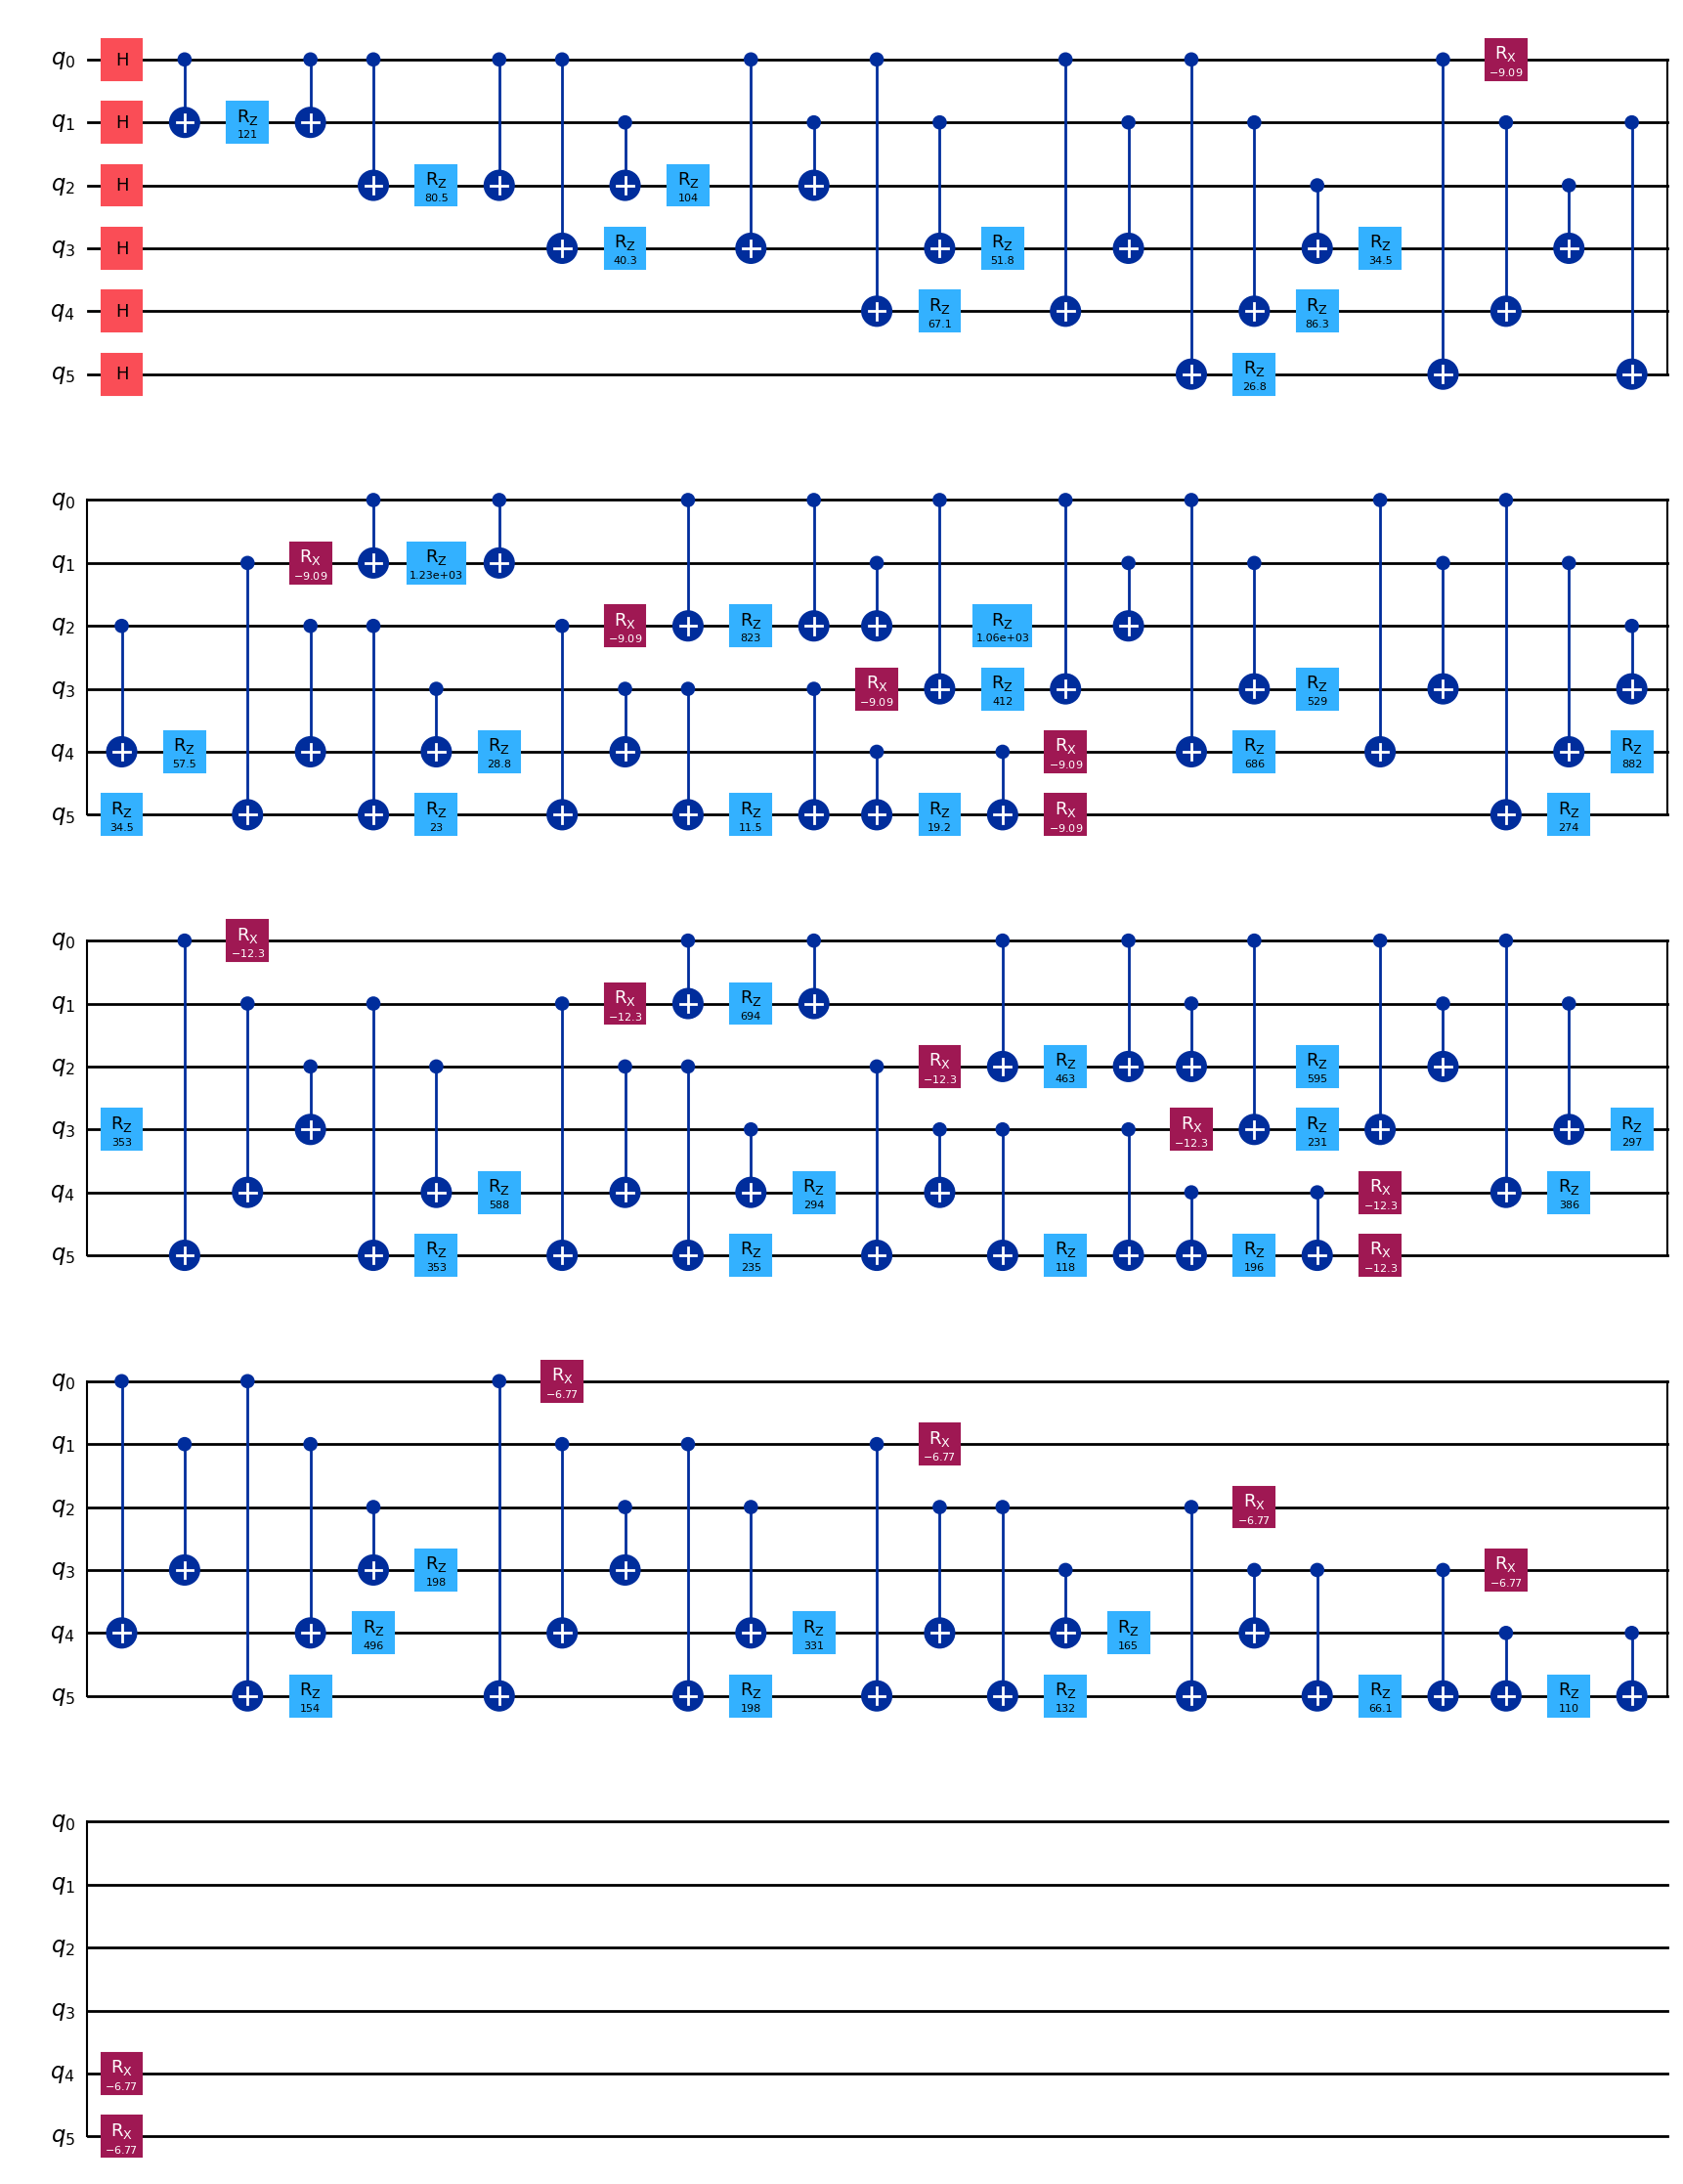

Epoch   0 | Reduced cost = -10.3097154017 | Original cost = 193.6902845983 | Grad norm = 9517.2256858122
Epoch  10 | Reduced cost = -9.9489876895 | Original cost = 194.0510123105 | Grad norm = 40008.5917283285
Epoch  20 | Reduced cost = 4.3645945603 | Original cost = 208.3645945603 | Grad norm = 37275.7938572521
Epoch  30 | Reduced cost = 1.1364619427 | Original cost = 205.1364619427 | Grad norm = 22885.5147399092
Epoch  40 | Reduced cost = -60.6118570760 | Original cost = 143.3881429240 | Grad norm = 11312.9797189589
Epoch  50 | Reduced cost = -51.5965307424 | Original cost = 152.4034692576 | Grad norm = 10931.3796411412
Epoch  60 | Reduced cost = -26.6884705874 | Original cost = 177.3115294126 | Grad norm = 42566.0901151692
Epoch  70 | Reduced cost = -31.4293582086 | Original cost = 172.5706417914 | Grad norm = 8277.6299345163
Epoch  80 | Reduced cost = 1.5013251562 | Original cost = 205.5013251562 | Grad norm = 25785.3661539038
Epoch  90 | Reduced cost = 58.5212060101 | Original cos

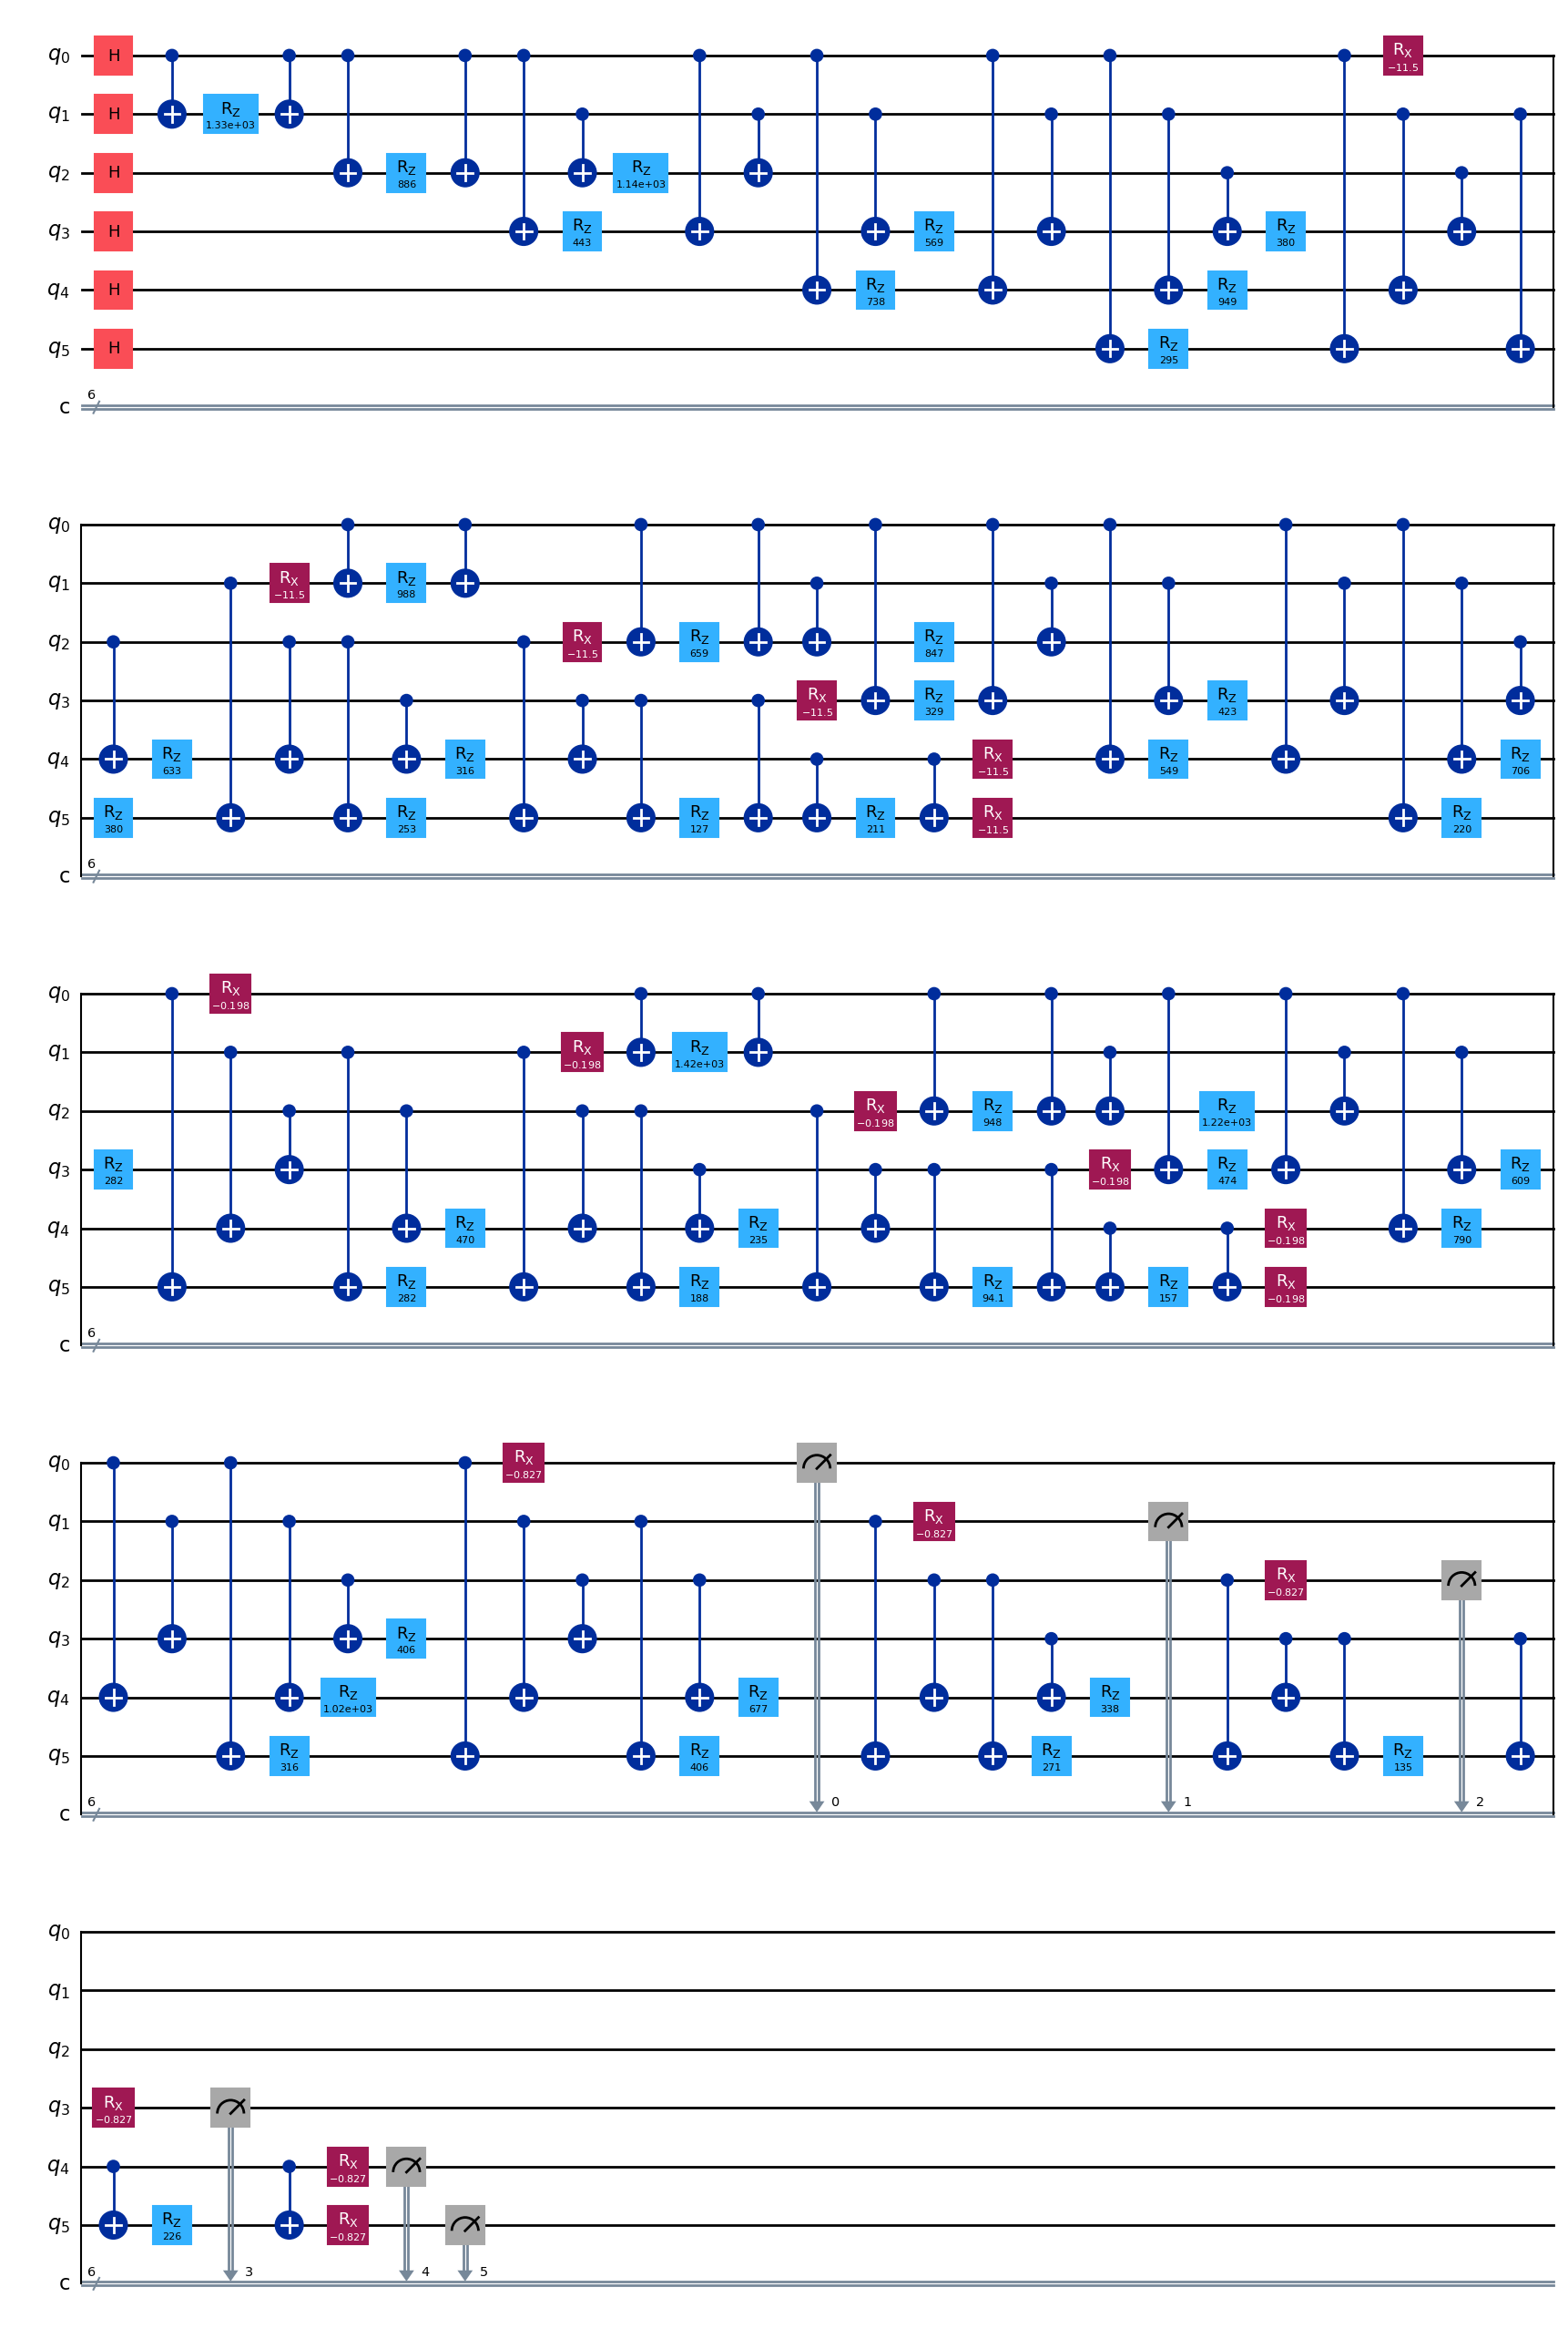


Measurement counts:
{'000001': 13, '101010': 223, '110110': 107, '100001': 51, '001010': 40, '111111': 69, '100010': 15, '111110': 10, '001011': 260, '010110': 93, '010010': 124, '100011': 30, '111101': 115, '001100': 14, '011011': 64, '010101': 203, '100111': 131, '111001': 98, '011110': 38, '101111': 12, '110001': 27, '000110': 88, '001001': 114, '001101': 15, '111100': 36, '100100': 45, '000011': 37, '101100': 35, '110100': 280, '001110': 20, '111011': 64, '100101': 112, '010111': 148, '101110': 2, '110010': 15, '000101': 21, '111010': 23, '100110': 18, '001111': 80, '011111': 40, '101001': 87, '011010': 98, '000100': 68, '110011': 22, '101101': 128, '101011': 3, '110101': 37, '000010': 118, '011000': 132, '101000': 157, '110111': 7, '000000': 78, '111000': 3, '100000': 47, '000111': 3, '110000': 69, '001000': 16, '010011': 31, '010000': 11, '011001': 15, '010100': 4, '011100': 17, '011101': 10, '010001': 5}


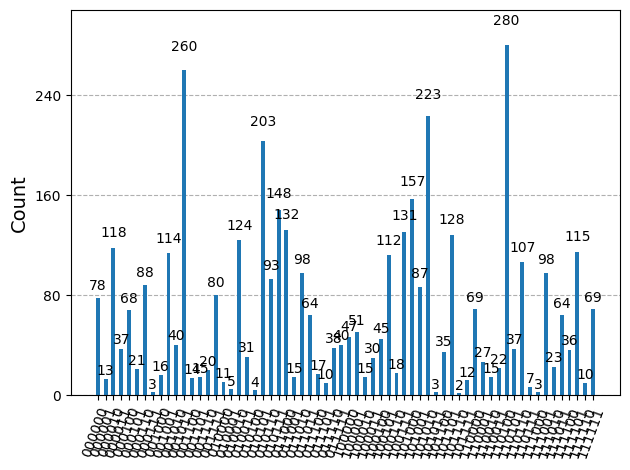


Most frequently measured candidate partitions:

Rank 1
Bitstring: 110100
Probability: 0.068359375
Group 1: [7.0, 9.0, 3.0]  Sum = 19.0
Group 2: [6.0, 5.0, 2.0]  Sum = 13.0
Absolute difference: 6.0
Squared difference: 36.0

Rank 2
Bitstring: 001011
Probability: 0.0634765625
Group 1: [6.0, 5.0, 2.0]  Sum = 13.0
Group 2: [7.0, 9.0, 3.0]  Sum = 19.0
Absolute difference: 6.0
Squared difference: 36.0

Rank 3
Bitstring: 101010
Probability: 0.054443359375
Group 1: [7.0, 6.0, 5.0]  Sum = 18.0
Group 2: [9.0, 3.0, 2.0]  Sum = 14.0
Absolute difference: 4.0
Squared difference: 16.0

Rank 4
Bitstring: 010101
Probability: 0.049560546875
Group 1: [9.0, 3.0, 2.0]  Sum = 14.0
Group 2: [7.0, 6.0, 5.0]  Sum = 18.0
Absolute difference: 4.0
Squared difference: 16.0

Rank 5
Bitstring: 101000
Probability: 0.038330078125
Group 1: [7.0, 9.0, 6.0, 5.0]  Sum = 27.0
Group 2: [3.0, 2.0]  Sum = 5.0
Absolute difference: 22.0
Squared difference: 484.0

Rank 6
Bitstring: 010111
Probability: 0.0361328125
Group 1: [3.0,

In [ ]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from IPython.display import display
from qiskit_aer import AerSimulator
import numpy as np
from numpy import pi
import itertools



# USER INPUT


raw = input(
    "Enter the numbers to partition, separated by spaces or commas\n"
    "Example: 1, 3, 4, 7, 13\n> "
)

numbers = [
    float(x)
    for x in raw.replace(",", " ").split()
]

if len(numbers) < 2:
    raise ValueError("Enter at least two numbers.")

n = len(numbers)

# QAOA / optimization choices
p = 3
shots = 4096
epochs = 250
lr = 0.01
seed = 7

print("\nNumbers:", numbers)
print("Number of qubits:", n)
print("QAOA layers p:", p)



# BASIC MATRICES


I = np.array([[1, 0],
              [0, 1]], dtype=complex)

Z = np.array([[1, 0],
              [0, -1]], dtype=complex)


def kron_all(op_list):
    """Tensor product of all matrices in op_list."""
    result = op_list[0]

    for op in op_list[1:]:
        result = np.kron(result, op)

    return result


def ZZ_on_pair(q1, q2):
    """
    Matrix for Z on qubits q1 and q2.

    Qiskit qubit 0 is the rightmost tensor factor.
    """
    ops = []

    for position in range(n):
        qiskit_qubit = n - 1 - position

        if qiskit_qubit == q1 or qiskit_qubit == q2:
            ops.append(Z)
        else:
            ops.append(I)

    return kron_all(ops)



# NUMBER-PARTITION COST HAMILTONIAN


# Original objective:
#
#     F(s) = (sum_i numbers[i] s_i)^2
#
# where s_i = +1 or -1.
#
# Expanding:
#
#     F(s) = sum_i numbers[i]^2
#            + 2 sum_{i<j} numbers[i] numbers[j] s_i s_j
#
# The first term is constant, so QAOA can minimize
#
#     Hc = sum_{i<j} J_ij Zi Zj
#
# with
#
#     J_ij = 2 numbers[i] numbers[j].

constant_shift = sum(value * value for value in numbers)

J = {}

for i in range(n):
    for j in range(i + 1, n):
        J[(i, j)] = 2.0 * numbers[i] * numbers[j]


# Build the reduced Hamiltonian matrix:
#
#     Hc = sum_{i<j} J_ij Zi Zj

Hc = np.zeros((2**n, 2**n), dtype=complex)

for (i, j), coeff in J.items():
    Hc = Hc + coeff * ZZ_on_pair(i, j)


def reduced_cost_from_statevector(state):
    """Expectation value <psi|Hc|psi> of the reduced Hamiltonian."""
    psi = state.data
    value = np.vdot(psi, Hc @ psi)

    return float(np.real(value))


def original_partition_cost_from_reduced_energy(reduced_energy):
    """
    Recover the original squared partition difference:

        F = reduced energy + sum_i numbers[i]^2
    """
    return reduced_energy + constant_shift



# QAOA LAYERS


def apply_cost_layer(qc, gamma):
    """
    Apply

        Uc(gamma) = exp(-i gamma Hc)

    where

        Hc = sum_{i<j} J_ij Zi Zj.

    For one term:

        exp(-i gamma J_ij Zi Zj)

    is implemented as

        CX(i,j) - RZ(2 gamma J_ij) on j - CX(i,j).
    """
    for (i, j), coeff in J.items():
        qc.cx(i, j)
        qc.rz(2.0 * gamma * coeff, j)
        qc.cx(i, j)


def apply_mixer_layer(qc, beta):
    """
    Mixer Hamiltonian:

        Hm = -sum_i Xi

    Therefore

        Um(beta) = exp(-i beta Hm)
                 = exp(+i beta sum_i Xi)

    and each qubit receives Rx(-2 beta).
    """
    for q in range(n):
        qc.rx(-2.0 * beta, q)


def build_qaoa_circuit(params, measure=False):
    """
    params = [gamma_1, ..., gamma_p, beta_1, ..., beta_p]
    """
    gammas = params[:p]
    betas = params[p:]

    qr = QuantumRegister(n, "q")

    if measure:
        cr = ClassicalRegister(n, "c")
        qc = QuantumCircuit(qr, cr)
    else:
        qc = QuantumCircuit(qr)

    # Uniform superposition of all partitions
    qc.h(qr)

    for layer in range(p):
        apply_cost_layer(qc, gammas[layer])
        apply_mixer_layer(qc, betas[layer])

    if measure:
        qc.measure(qr, cr)

    return qc


def cost_function(params):
    qc = build_qaoa_circuit(params, measure=False)
    state = Statevector.from_instruction(qc)

    return reduced_cost_from_statevector(state)



# SHIFT ONE COST GATE FOR THE PSR


def apply_cost_layer_with_one_gate_shifted(
    qc,
    gamma,
    shifted_pair,
    shifted_alpha
):
    """
    Normally, pair (i,j) has

        alpha_ij = gamma J_ij

    inside exp(-i alpha_ij ZiZj).

    For one selected pair, replace alpha_ij by shifted_alpha.
    """
    for pair, coeff in J.items():
        i, j = pair

        if pair == shifted_pair:
            alpha = shifted_alpha
        else:
            alpha = gamma * coeff

        qc.cx(i, j)
        qc.rz(2.0 * alpha, j)
        qc.cx(i, j)


def build_circuit_one_cost_gate_shifted(
    params,
    layer_to_shift,
    shifted_pair,
    shifted_alpha
):
    gammas = params[:p]
    betas = params[p:]

    qr = QuantumRegister(n, "q")
    qc = QuantumCircuit(qr)

    qc.h(qr)

    for layer in range(p):

        if layer == layer_to_shift:
            apply_cost_layer_with_one_gate_shifted(
                qc=qc,
                gamma=gammas[layer],
                shifted_pair=shifted_pair,
                shifted_alpha=shifted_alpha
            )
        else:
            apply_cost_layer(qc, gammas[layer])

        apply_mixer_layer(qc, betas[layer])

    return qc


def cost_with_one_cost_gate_shifted(
    params,
    layer_to_shift,
    shifted_pair,
    shifted_alpha
):
    qc = build_circuit_one_cost_gate_shifted(
        params=params,
        layer_to_shift=layer_to_shift,
        shifted_pair=shifted_pair,
        shifted_alpha=shifted_alpha
    )

    state = Statevector.from_instruction(qc)

    return reduced_cost_from_statevector(state)



# SHIFT ONE MIXER GATE FOR THE PSR


def apply_mixer_layer_with_one_gate_shifted(
    qc,
    beta,
    qubit_to_shift,
    shifted_beta
):
    for q in range(n):

        if q == qubit_to_shift:
            qc.rx(-2.0 * shifted_beta, q)
        else:
            qc.rx(-2.0 * beta, q)


def build_circuit_one_mixer_gate_shifted(
    params,
    layer_to_shift,
    qubit_to_shift,
    shifted_beta
):
    gammas = params[:p]
    betas = params[p:]

    qr = QuantumRegister(n, "q")
    qc = QuantumCircuit(qr)

    qc.h(qr)

    for layer in range(p):
        apply_cost_layer(qc, gammas[layer])

        if layer == layer_to_shift:
            apply_mixer_layer_with_one_gate_shifted(
                qc=qc,
                beta=betas[layer],
                qubit_to_shift=qubit_to_shift,
                shifted_beta=shifted_beta
            )
        else:
            apply_mixer_layer(qc, betas[layer])

    return qc


def cost_with_one_mixer_gate_shifted(
    params,
    layer_to_shift,
    qubit_to_shift,
    shifted_beta
):
    qc = build_circuit_one_mixer_gate_shifted(
        params=params,
        layer_to_shift=layer_to_shift,
        qubit_to_shift=qubit_to_shift,
        shifted_beta=shifted_beta
    )

    state = Statevector.from_instruction(qc)

    return reduced_cost_from_statevector(state)



# PARAMETER-SHIFT-RULE GRADIENT


def gradient_psr(params):
    """
    Correct PSR for shared QAOA parameters.

    gamma_k occurs in every cost gate of layer k.
    beta_k occurs in every mixer gate of layer k.

    Therefore, shift one physical gate at a time and add all
    contributions using the chain rule.
    """
    grad = np.zeros_like(params, dtype=float)

    # For gates exp(+-i alpha P), with P^2 = I:
    shift = pi / 4.0

    
    # dC / d gamma_k
    
    for layer in range(p):
        gamma = params[layer]
        total = 0.0

        for pair, coeff in J.items():
            alpha = gamma * coeff

            plus_cost = cost_with_one_cost_gate_shifted(
                params=params,
                layer_to_shift=layer,
                shifted_pair=pair,
                shifted_alpha=alpha + shift
            )

            minus_cost = cost_with_one_cost_gate_shifted(
                params=params,
                layer_to_shift=layer,
                shifted_pair=pair,
                shifted_alpha=alpha - shift
            )

            # alpha = coeff * gamma
            # dC/dgamma = coeff * dC/dalpha
            total += coeff * (plus_cost - minus_cost)

        grad[layer] = total

    
    # dC / d beta_k
    
    for layer in range(p):
        beta_index = p + layer
        beta = params[beta_index]
        total = 0.0

        for q in range(n):
            plus_cost = cost_with_one_mixer_gate_shifted(
                params=params,
                layer_to_shift=layer,
                qubit_to_shift=q,
                shifted_beta=beta + shift
            )

            minus_cost = cost_with_one_mixer_gate_shifted(
                params=params,
                layer_to_shift=layer,
                qubit_to_shift=q,
                shifted_beta=beta - shift
            )

            total += plus_cost - minus_cost

        grad[beta_index] = total

    return grad


def gradient_numerical(params, eps=1e-6):
    """Finite-difference gradient used only to verify the PSR."""
    grad = np.zeros_like(params, dtype=float)

    for i in range(len(params)):
        plus = params.copy()
        minus = params.copy()

        plus[i] += eps
        minus[i] -= eps

        grad[i] = (
            cost_function(plus) - cost_function(minus)
        ) / (2.0 * eps)

    return grad



# BITSTRING / PARTITION UTILITIES


def decode_qiskit_bitstring(bitstring):
    """
    Qiskit prints c[n-1]...c[1]c[0].

    Reverse the displayed string so list position i corresponds
    to qubit i and therefore to numbers[i].
    """
    clean = bitstring.replace(" ", "")
    return [int(bit) for bit in clean[::-1]]


def partition_from_bitstring(bitstring):
    """
    |0> has Z eigenvalue +1 and is assigned to group 1.
    |1> has Z eigenvalue -1 and is assigned to group 2.
    """
    bits = decode_qiskit_bitstring(bitstring)

    group_1 = []
    group_2 = []

    for i, bit in enumerate(bits):
        if bit == 0:
            group_1.append(numbers[i])
        else:
            group_2.append(numbers[i])

    sum_1 = sum(group_1)
    sum_2 = sum(group_2)
    difference = abs(sum_1 - sum_2)
    squared_difference = difference**2

    return group_1, group_2, sum_1, sum_2, difference, squared_difference


def exact_best_partition():
    """
    Brute-force verification.

    This is exponential and should only be used for modest n.
    Complementary bitstrings describe the same partition with
    the two group labels exchanged.
    """
    if n > 24:
        return None

    best = None

    for bits in itertools.product([0, 1], repeat=n):
        group_1 = [
            numbers[i]
            for i in range(n)
            if bits[i] == 0
        ]

        group_2 = [
            numbers[i]
            for i in range(n)
            if bits[i] == 1
        ]

        difference = abs(sum(group_1) - sum(group_2))

        if best is None or difference < best["difference"]:
            # Convert q0...q(n-1) to Qiskit's displayed order
            qiskit_bitstring = "".join(str(bit) for bit in bits[::-1])

            best = {
                "bitstring": qiskit_bitstring,
                "group_1": group_1,
                "group_2": group_2,
                "sum_1": sum(group_1),
                "sum_2": sum(group_2),
                "difference": difference,
                "squared_difference": difference**2
            }

    return best



# INITIALIZATION


np.random.seed(seed)

params = np.random.uniform(
    low=0.0,
    high=2.0 * pi,
    size=2 * p
)

print("\nInitial parameters:")
print(params)

initial_reduced_cost = cost_function(params)

print("\nInitial reduced Hamiltonian cost:")
print(initial_reduced_cost)

print("\nInitial original squared-difference expectation:")
print(
    original_partition_cost_from_reduced_energy(
        initial_reduced_cost
    )
)



# CHECK PSR AGAINST FINITE DIFFERENCE


print("\nChecking the PSR gradient at the initial point...")

g_psr = gradient_psr(params)
g_num = gradient_numerical(params)

print("\nPSR gradient:")
print(g_psr)

print("\nNumerical gradient:")
print(g_num)

print("\nPSR - numerical:")
print(g_psr - g_num)

print("\nMaximum absolute gradient difference:")
print(np.max(np.abs(g_psr - g_num)))



# SHOW INITIAL CIRCUIT


initial_qc = build_qaoa_circuit(params, measure=False)
display(initial_qc.draw(output="mpl"))



# GRADIENT DESCENT


cost_history = []

for epoch in range(epochs):
    reduced_cost = cost_function(params)
    cost_history.append(reduced_cost)

    grad = gradient_psr(params)

    params = params - lr * grad

    # Optional angle wrapping
    params = np.mod(params, 2.0 * pi)

    if epoch % 10 == 0:
        original_cost = (
            original_partition_cost_from_reduced_energy(
                reduced_cost
            )
        )

        print(
            f"Epoch {epoch:3d} | "
            f"Reduced cost = {reduced_cost:.10f} | "
            f"Original cost = {original_cost:.10f} | "
            f"Grad norm = {np.linalg.norm(grad):.10f}"
        )



# FINAL RESULTS


final_reduced_cost = cost_function(params)
final_original_cost = (
    original_partition_cost_from_reduced_energy(
        final_reduced_cost
    )
)

print("\nFinal parameters:")
print(params)

print("\nFinal reduced Hamiltonian cost:")
print(final_reduced_cost)

print("\nFinal original squared-difference expectation:")
print(final_original_cost)



# FINAL CIRCUIT AND MEASUREMENT


final_qc = build_qaoa_circuit(params, measure=True)
display(final_qc.draw(output="mpl"))

simulator = AerSimulator()

result = simulator.run(
    final_qc,
    shots=shots
).result()

counts = result.get_counts()

print("\nMeasurement counts:")
print(counts)

display(plot_histogram(counts))



# INTERPRET THE MOST LIKELY MEASURED PARTITIONS


sorted_counts = sorted(
    counts.items(),
    key=lambda item: item[1],
    reverse=True
)

print("\nMost frequently measured candidate partitions:")

for rank, (bitstring, count) in enumerate(sorted_counts[:10], start=1):
    (
        group_1,
        group_2,
        sum_1,
        sum_2,
        difference,
        squared_difference
    ) = partition_from_bitstring(bitstring)

    probability = count / shots

    print(f"\nRank {rank}")
    print("Bitstring:", bitstring)
    print("Probability:", probability)
    print("Group 1:", group_1, " Sum =", sum_1)
    print("Group 2:", group_2, " Sum =", sum_2)
    print("Absolute difference:", difference)
    print("Squared difference:", squared_difference)



# EXACT CLASSICAL CHECK FOR SMALL INPUTS


exact = exact_best_partition()

if exact is not None:
    print("\nExact best partition from brute-force verification:")
    print("Bitstring:", exact["bitstring"])
    print("Group 1:", exact["group_1"], " Sum =", exact["sum_1"])
    print("Group 2:", exact["group_2"], " Sum =", exact["sum_2"])
    print("Absolute difference:", exact["difference"])
    print("Squared difference:", exact["squared_difference"])
else:
    print(
        "\nExact brute-force verification skipped because n > 24."
    )